In [24]:
import nbformat
from nbconvert import PythonExporter
import os
import pandas as pd
import plotly.express as px  


notebook_paths = [
    'src/option_price/exact_option_pricing.ipynb',
    'src/option_price/qmc_option_pricing.ipynb',
    'src/seq/class_modify_sobol.ipynb',
    'test/test.ipynb'
]

# Текущая рабочая директория
current_dir = os.getcwd()
parent_dir = os.path.join(current_dir, '..')
for notebook_path in notebook_paths:
    
    full_path = os.path.join(current_dir, notebook_path)  # формируем полный путь

    if not os.path.isfile(full_path):
        print(f"❌ Файл не найден: {full_path}")
        continue

    try:
        print(f"🚀 Выполняется: {full_path}")

        # Читаем ноутбук
        with open(full_path, 'r', encoding='utf-8') as f:
            notebook_content = nbformat.read(f, as_version=4)

        # Конвертируем ноутбук в Python-код
        python_exporter = PythonExporter()
        python_code, _ = python_exporter.from_notebook_node(notebook_content)

        # Выполняем к
        exec(python_code)

        print(f"✅ Успешно выполнен: {full_path}")

    except Exception as e:
        print(f"⚠️ Ошибка в {full_path}: {e}")

🚀 Выполняется: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/option_price/exact_option_pricing.ipynb
✅ Успешно выполнен: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/option_price/exact_option_pricing.ipynb
🚀 Выполняется: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/option_price/qmc_option_pricing.ipynb
✅ Успешно выполнен: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/option_price/qmc_option_pricing.ipynb
🚀 Выполняется: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/seq/class_modify_sobol.ipynb
✅ Успешно выполнен: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\src/seq/class_modify_sobol.ipynb
🚀 Выполняется: C:\Users\Vlada\Desktop\Sirius\NIR\quasi_monte_carlo_method\test/test.ipynb
❌ Файл не найден: C:\Users\Vlada\Desktop\Sirius\NIR\src\option_price\exact_option_pricing.ipynb
❌ Файл не найден: C:\Users\Vlada\Desktop\Sirius\NIR\src\option_price\qmc_option_pricing.ipynb
❌ Файл не найден: C:\Us

### Функции

In [25]:
def graph_one_2D(arr, d_1, d_2, title: str, color: str):
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(x=arr[:,d_1-1], y=arr[:,d_2-1], mode='markers', line=dict(color=color)))

    fig.update_layout(
        title=title,
        xaxis_title=f'dim={d_1}',
        yaxis_title=f'dim={d_2}',
        width=500,
        height=500,
        template='plotly_white'
    )
    
    fig.show()


In [26]:
def _1D_gaph(data,title_):
    fig = go.Figure()

    fig.add_trace(go.Scatter(x=data, y=[0] * len(data), mode='lines+markers', 
                             line=dict(color='lightblue'), 
                             marker=dict(color='black', size=7),
                             name='Data'))
    fig.update_layout(
        title= title_,
        xaxis=dict(title='X-axis'),
        yaxis=dict(visible=False),  # cкрытие оси Y
        showlegend=True,
        autosize=False,
        width=1000,
        height=300,
        plot_bgcolor='rgba(128, 128, 128, 0.2)',  
        paper_bgcolor='white',
        title_x=0.5
    )

    fig.show()

In [42]:
# 3D график
def graph_3d(arr, d_1, d_2, d_3):
    fig = go.Figure()

    fig.add_trace(go.Scatter3d(x=arr[:,d_1-1], y=arr[:,d_2-1], z=arr[:,d_3-1], mode='markers', 
                             marker=dict(color='lightgreen', size=5, 
                                         line=dict(color='purple', width=0.5)), 
                             name='Data'))

    fig.update_layout(
        scene=dict(
            xaxis_title=f'dim = {d_1}',
            yaxis_title=f'dim = {d_2}',
            zaxis_title=f'dim = {d_3}',
        ),
        width=800,
        height=800,
        scene_aspectmode='cube',
        plot_bgcolor='rgba(128, 128, 128, 0.2)',  
        paper_bgcolor='white'
    )

    fig.show()


In [31]:
def farei_sequence(n):
    result = ['0/1']
    
    def farei_sequence_rec(n, x, y, z, t):
        a, b = x + z, y + t
        if b <= n:
            farei_sequence_rec(n, x, y, a, b)
            result.append(f'{a}/{b}')
            farei_sequence_rec(n, a, b, z, t)
      
    farei_sequence_rec(n, 0, 1, 1, 1)
    result.append('1/1')
    return result

### Классический Фарей

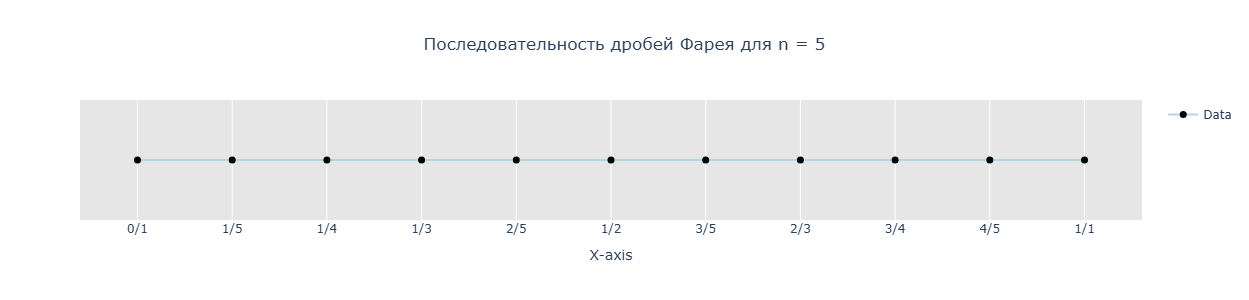

In [32]:
F_L = farei_sequence(5) 
title__= "Последовательность дробей Фарея для n = 5"
_1D_gaph(F_L, title__)

### Модифицированный Фарей

In [33]:
dim = 100
m = 10
n0 = 1
seq_= LowDiscrepancySequence(dim, n0, m)
arr = seq_.get_seq('sobol_farey')

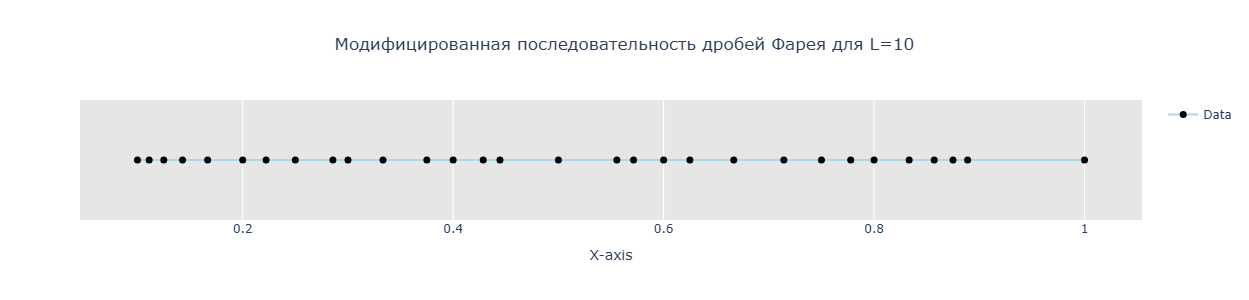

In [34]:
F_L = seq_.farey_seq(30) 
title_ = "Модифицированная последовательность дробей Фарея для L=10"
van_der_corput_gaph(F_L, title_)

### Многомерный Соболь-Фарей

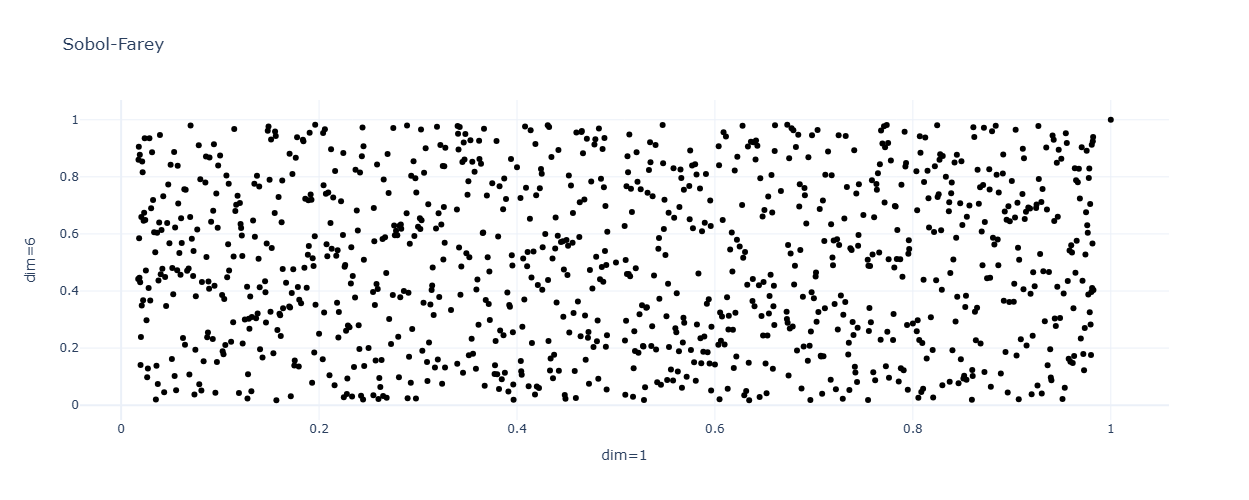

In [35]:
d_1 = 1
d_2 = 6
title ='Sobol-Farey'
color = 'black'
graph_one_2D(arr, d_1, d_2, title, color)

### Сравнение Дискрипанси

In [43]:
def dic(dim, m):
    n0 = 1
    sequence = []
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('sobol_farey'))
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('sobol_lcg'))
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('halton'))
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('kronecker'))
    # sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('sobol_kronecker'))
    sequence.append(LowDiscrepancySequence(dim, n0, m).get_seq('faure'))
    sequence.append(qmc.Sobol(d=dim, scramble=False).random_base2(m+1)[1:2**m+1])
   
    disc = []
    for i in sequence:
        disc.append(qmc.discrepancy(i))
    # disc = pd.DataFrame(disc)
    return disc

In [44]:
dim_ =15
arr = []

for d in tqdm(range(dim_)):
    m = 13
    dim = d + 1
    arr.append(dic(dim, m))

df0 = pd.DataFrame(arr, index = range(1, dim_ + 1), columns = ['sobol_farey', 'sobol_lcg', 'halton','kronecker','faure','sobol'])

100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [05:51<00:00, 23.45s/it]


In [45]:
df0

,sobol_farey,sobol_lcg,halton,kronecker,faure,sobol
1,0.000002,0.000008,2.483830e-09,1.170124e-08,4.966599e-09,4.966599e-09
2,0.000059,0.000040,9.619634e-08,6.757573e-08,2.312560e-08,2.027887e-08
3,0.000106,0.000064,3.397809e-07,8.123432e-07,2.137369e-07,6.921785e-08
4,0.000216,0.000093,7.942970e-07,3.665840e-06,8.740844e-07,2.447245e-07
5,0.000362,0.000131,1.945214e-06,5.201778e-06,1.750287e-06,8.097047e-07
6,0.000574,0.000189,4.206939e-06,2.597849e-05,4.471648e-06,1.944067e-06
7,0.000925,0.000262,9.682287e-06,4.384898e-05,8.196381e-06,4.442652e-06
8,0.001549,0.000371,1.849439e-05,6.462401e-05,2.352928e-05,1.076676e-05
9,0.002163,0.000499,3.315772e-05,2.504976e-04,3.776485e-05,2.253123e-05
10,0.002902,0.000674,7.913880e-05,3.201693e-04,6.014543e-05,4.275145e-05


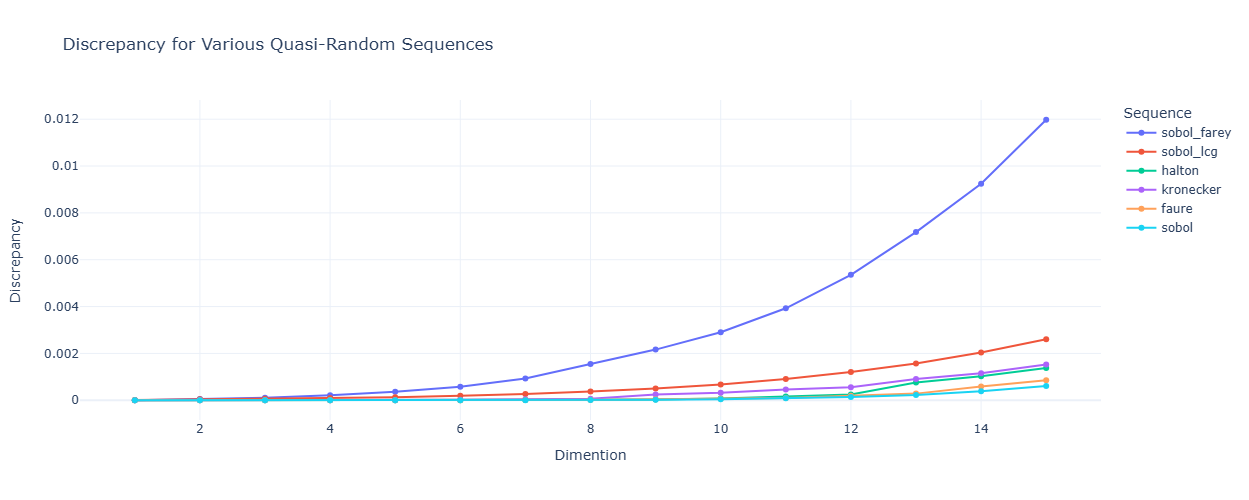

In [46]:
df0.index = range(1, len(df0) + 1)

df_long = df0.reset_index().melt(
    id_vars='index',
    value_vars=['sobol_farey', 'sobol_lcg', 'halton','kronecker','faure','sobol'],
    var_name='Sequence',
    value_name='Discrepancy'
)

# Построим график
fig = px.line(
    df_long,
    x='index',
    y='Discrepancy',
    color='Sequence',
    markers=True,
    title='Discrepancy for Various Quasi-Random Sequences'
)

fig.update_layout(
    xaxis_title='Dimention',
    yaxis_title='Discrepancy',
    template='plotly_white',
    width=1000,
    height=500
)


fig.show()


<Axes: >

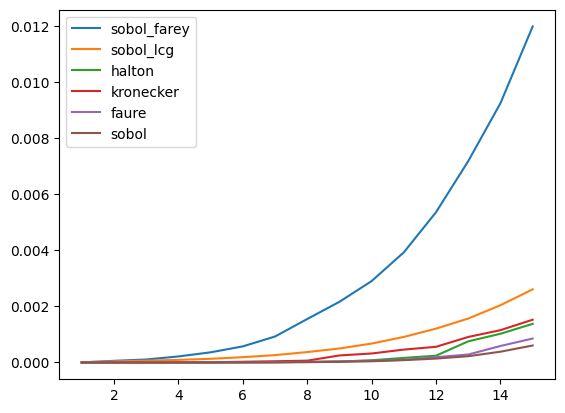

In [47]:
df0.plot()

---

### Ценообразование опционов

In [48]:
dim = 15
m = 13
sequences_names = ['sobol_farey', 'sobol_lcg', 'halton','kronecker','faure','sobol']

sobol_seq = Test_seq( dim, m, sequences_names)

In [49]:
S_0 = 95 
K = 100  
r = 0.21
sigma = 0.2  
T = 1
option_type="call"
t = 0.0
B = 150
S_max = 150

options_data = [S_0, K, r, sigma, T, option_type, t, B, S_max]



In [50]:
sobol_seq.find_options_prices(options_data)

Обработка последовательностей: 100%|█████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.49it/s]


,European_Option_Payoff,Up_and_Out_Payoff,Lookback_Option_Payoff
sobol_farey,16.316674,9.824605,28.022249
sobol_lcg,17.056019,10.867580,26.934383
halton,16.404171,10.378561,28.285451
kronecker,21.259203,12.874917,21.642935
faure,18.319884,11.080189,26.064764
sobol,15.991652,10.501201,28.160170
exact_answer,16.069162,11.254618,28.328486


In [51]:
sobol_seq.find_options_errors(options_data)

Обработка последовательностей: 100%|█████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.13it/s]


,European_Option_Payoff,Up_and_Out_Payoff,Lookback_Option_Payoff
sobol_farey,0.247512,-1.430013,-0.306237
sobol_lcg,0.986857,-0.387038,-1.394103
halton,0.335009,-0.876057,-0.043035
kronecker,5.190041,1.620299,-6.685551
faure,2.250722,-0.174430,-2.263722
sobol,-0.077510,-0.753417,-0.168316


In [52]:
df = sobol_seq.find__options_prices_time_steps(options_data)
df 

European                                                         \
    sobol_farey  sobol_lcg     halton  kronecker      faure      sobol   
0.0   16.316674  17.056019  16.404171  21.259203  18.319884  15.991652   
0.1   14.449561  15.116299  14.516523  18.915915  16.253020  14.149946   
0.2   12.632100  13.222019  12.677666  16.624427  14.234255  12.360043   
0.3   10.863505  11.373517  10.889186  14.376688  12.261769  10.619820   
0.4    9.141099   9.570277   9.149225  12.175540  10.335769   8.925853   
0.5    7.463325   7.810853   7.453451  10.013514   8.452473   7.279885   
0.6    5.829739   6.090244   5.800021   7.882912   6.607487   5.670250   
0.7    4.232677   4.402239   4.187794   5.771758   4.799552   4.093149   
0.8    2.667094   2.747024   2.615512   3.676240   3.016949   2.550945   
0.9    1.138005   1.136086   1.086137   1.583637   1.269944   1.046108   
1.0    0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   

                Up-and-Out                        ...                        \
         exact sobol_farey  sobol_lcg     halton  ...      faure      sobol   
0.0  16.069162    9.824605  10.867580  10.378561  ...  11.080189  10.501201   
0.1  14.516267    9.996444  11.074185  10.287203  ...  11.400079  10.426101   
0.2  12.939940    9.633976  10.865240  10.238153  ...  11.374134  10.263639   
0.3  11.340207    9.337148  10.275588   9.762879  ...  10.941017   9.725940   
0.4   9.716986    8.972070   9.410048   9.035388  ...  10.120728   8.909803   
0.5   8.069989    7.890828   8.300585   8.015297  ...   8.895414   7.760409   
0.6   6.398593    6.539084   6.807957   6.546091  ...   7.410072   6.352230   
0.7   4.701799    4.902884   5.084335   4.850948  ...   5.559580   4.741311   
0.8   2.979385    3.155004   3.249555   3.093985  ...   3.568860   3.017606   
0.9   1.246290    1.374756   1.372438   1.312098  ...   1.534144   1.263742   
1.0   0.000000    0.000000   0.000000   0.000000  ...   0.000000   0.000000   

                  Lookback                                              \
         exact sobol_farey  sobol_lcg     halton  kronecker      faure   
0.0  11.254618   28.022249  26.934383  28.285451  21.642935  26.064764   
0.1  11.048789   30.082322  29.070792  30.373625  23.850526  28.177365   
0.2  10.630777   32.287684  31.380494  32.625031  26.282882  30.491925   
0.3   9.964028   34.646844  33.860915  35.044405  28.943836  32.998654   
0.4   9.021724   37.185092  36.501360  37.612306  31.839055  35.677064   
0.5   7.799725   39.904996  39.293113  40.324562  34.968678  38.520014   
0.6   6.331920   42.757815  42.205785  43.142325  38.306215  41.514723   
0.7   4.695120   45.708298  45.217257  46.034639  41.835132  44.623099   
0.8   2.979313   48.731411  48.321734  48.984479  45.562938  47.833622   
0.9   1.246290   51.821564  51.525192  51.988344  49.576447  51.176100   
1.0   0.000000   55.000000  55.000000  55.000000  55.000000  55.000000   

                           
         sobol      exact  
0.0  28.160170  28.328486  
0.1  30.275627  30.328568  
0.2  32.564326  32.510595  
0.3  35.005742  34.874608  
0.4  37.583097  37.412450  
0.5  40.294853  40.105752  
0.6  43.105308  42.926374  
0.7  45.999715  45.842434  
0.8  48.960735  48.830474  
0.9  51.975982  51.882845  
1.0  55.000000  55.000000  

[11 rows x 21 columns]

In [53]:
title = 'European option'
dff = df['European']
sobol_seq.plot_option(dff, title)

In [54]:
title2 = 'Up-and-Out option'
dff2 = df['Up-and-Out']
sobol_seq.plot_option(dff2, title2)

In [55]:
title3 = 'Lookback option'
dff3 = df['Lookback']
sobol_seq.plot_option(dff3, title3)

In [56]:
dff3

,sobol_farey,sobol_lcg,halton,kronecker,faure,sobol,exact
0.0,28.022249,26.934383,28.285451,21.642935,26.064764,28.160170,28.328486
0.1,30.082322,29.070792,30.373625,23.850526,28.177365,30.275627,30.328568
0.2,32.287684,31.380494,32.625031,26.282882,30.491925,32.564326,32.510595
0.3,34.646844,33.860915,35.044405,28.943836,32.998654,35.005742,34.874608
0.4,37.185092,36.501360,37.612306,31.839055,35.677064,37.583097,37.412450
0.5,39.904996,39.293113,40.324562,34.968678,38.520014,40.294853,40.105752
0.6,42.757815,42.205785,43.142325,38.306215,41.514723,43.105308,42.926374
0.7,45.708298,45.217257,46.034639,41.835132,44.623099,45.999715,45.842434
0.8,48.731411,48.321734,48.984479,45.562938,47.833622,48.960735,48.830474
0.9,51.821564,51.525192,51.988344,49.576447,51.176100,51.975982,51.882845


#### Ошибки стоимости опционов на промежутке времени от t до T

In [57]:
error_european_option = dff3.apply(lambda x: x - dff3['exact'], axis=0)
error_up_and_out_option = dff2.apply(lambda x: x - dff2['exact'], axis=0)
error_lookback_option = dff.apply(lambda x: x - dff['exact'], axis=0)


In [58]:
def plot_option(df, title, yaxis_title, width, height):
    fig = go.Figure()
    

    for col in df.columns:
        fig.add_trace(go.Scatter(x=df.index, 
                                 y=df[col], 
                                 mode='lines+markers', 
                                 name=col))

    # Настройка графика
    fig.update_layout(title=title,
                      xaxis_title='Time steps',
                      yaxis_title=yaxis_title,
                      template='plotly_white',
                      width=width,
                      height=height)
    
    return fig



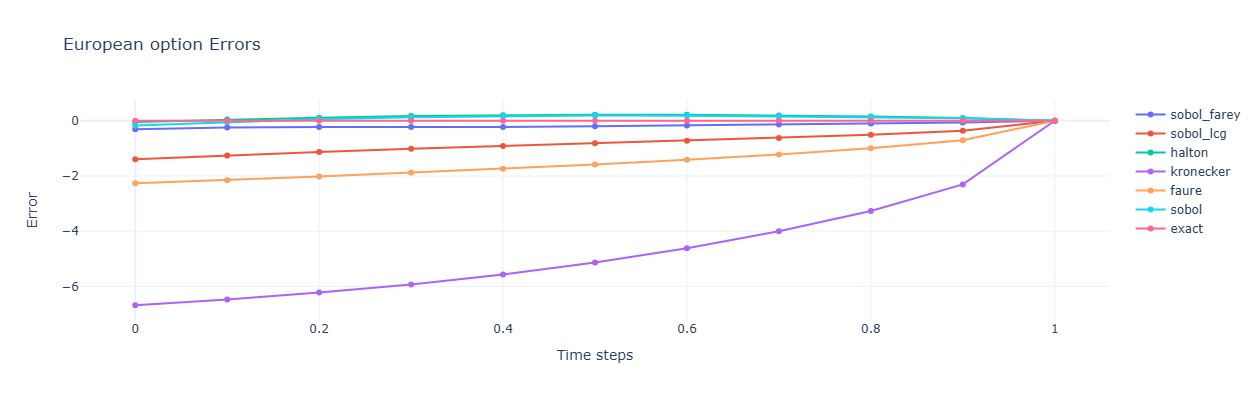

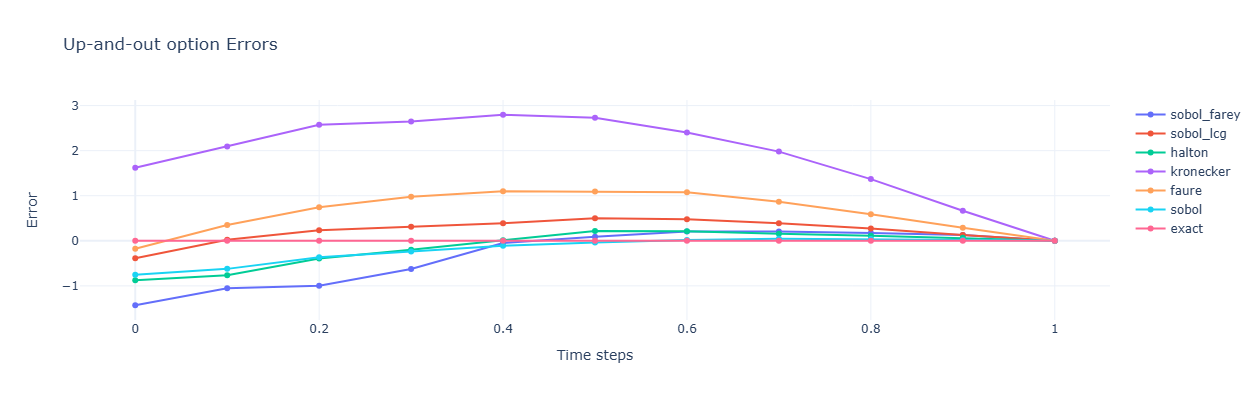

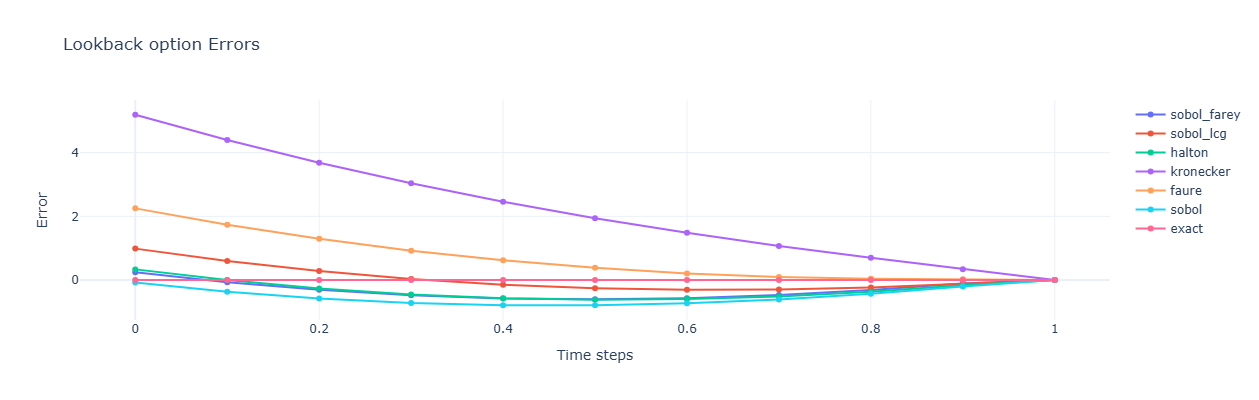

In [59]:
fig_error_european_option = plot_option(error_european_option, 'European option Errors', 'Error', width=1200, height=400)
fig_error_up_and_out_option = plot_option(error_up_and_out_option, 'Up-and-out option Errors', 'Error', width=1200, height=400)
fig_error_lookback_option = plot_option(error_lookback_option, 'Lookback option Errors', 'Error', width=1200, height=400)

fig_error_european_option.show()
fig_error_up_and_out_option.show()
fig_error_lookback_option.show()